<a href="https://colab.research.google.com/github/mohit22617/House-price-prediction/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shree1992/housedata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housedata' dataset.
Path to dataset files: /kaggle/input/housedata


In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler





In [74]:
df = pd.read_csv("data.csv")

In [75]:
y = df['price']
df.drop(columns=['price'], inplace=True)

In [76]:
df.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [78]:
df.select_dtypes(include='object')

,date,street,city,statezip,country
0,2014-05-02 00:00:00,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...
4595,2014-07-09 00:00:00,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,5148 S Creston St,Seattle,WA 98178,USA


In [89]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df.drop("date", axis=1, inplace=True)

In [90]:
df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,year,month
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,2014,5
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,2014,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,2014,7
4596,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,2014,7
4597,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,2014,7
4598,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,2014,7


KeyError: "None of [Index(['city'], dtype='object')] are in the [columns]"

In [93]:
def detect_outliers_iqr(df): # Function to detect outliers based on IQR
    outlier_count = {}
    for column in df.select_dtypes(include='number'):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outlier_count[column] = outliers.shape[0]
    return outlier_count



In [94]:
detect_outliers_iqr(df)

{'bedrooms': 118,
 'bathrooms': 141,
 'sqft_living': 129,
 'sqft_lot': 541,
 'floors': 0,
 'waterfront': 33,
 'view': 460,
 'condition': 6,
 'sqft_above': 116,
 'sqft_basement': 82,
 'yr_built': 0,
 'yr_renovated': 0,
 'year': 0,
 'month': 0}

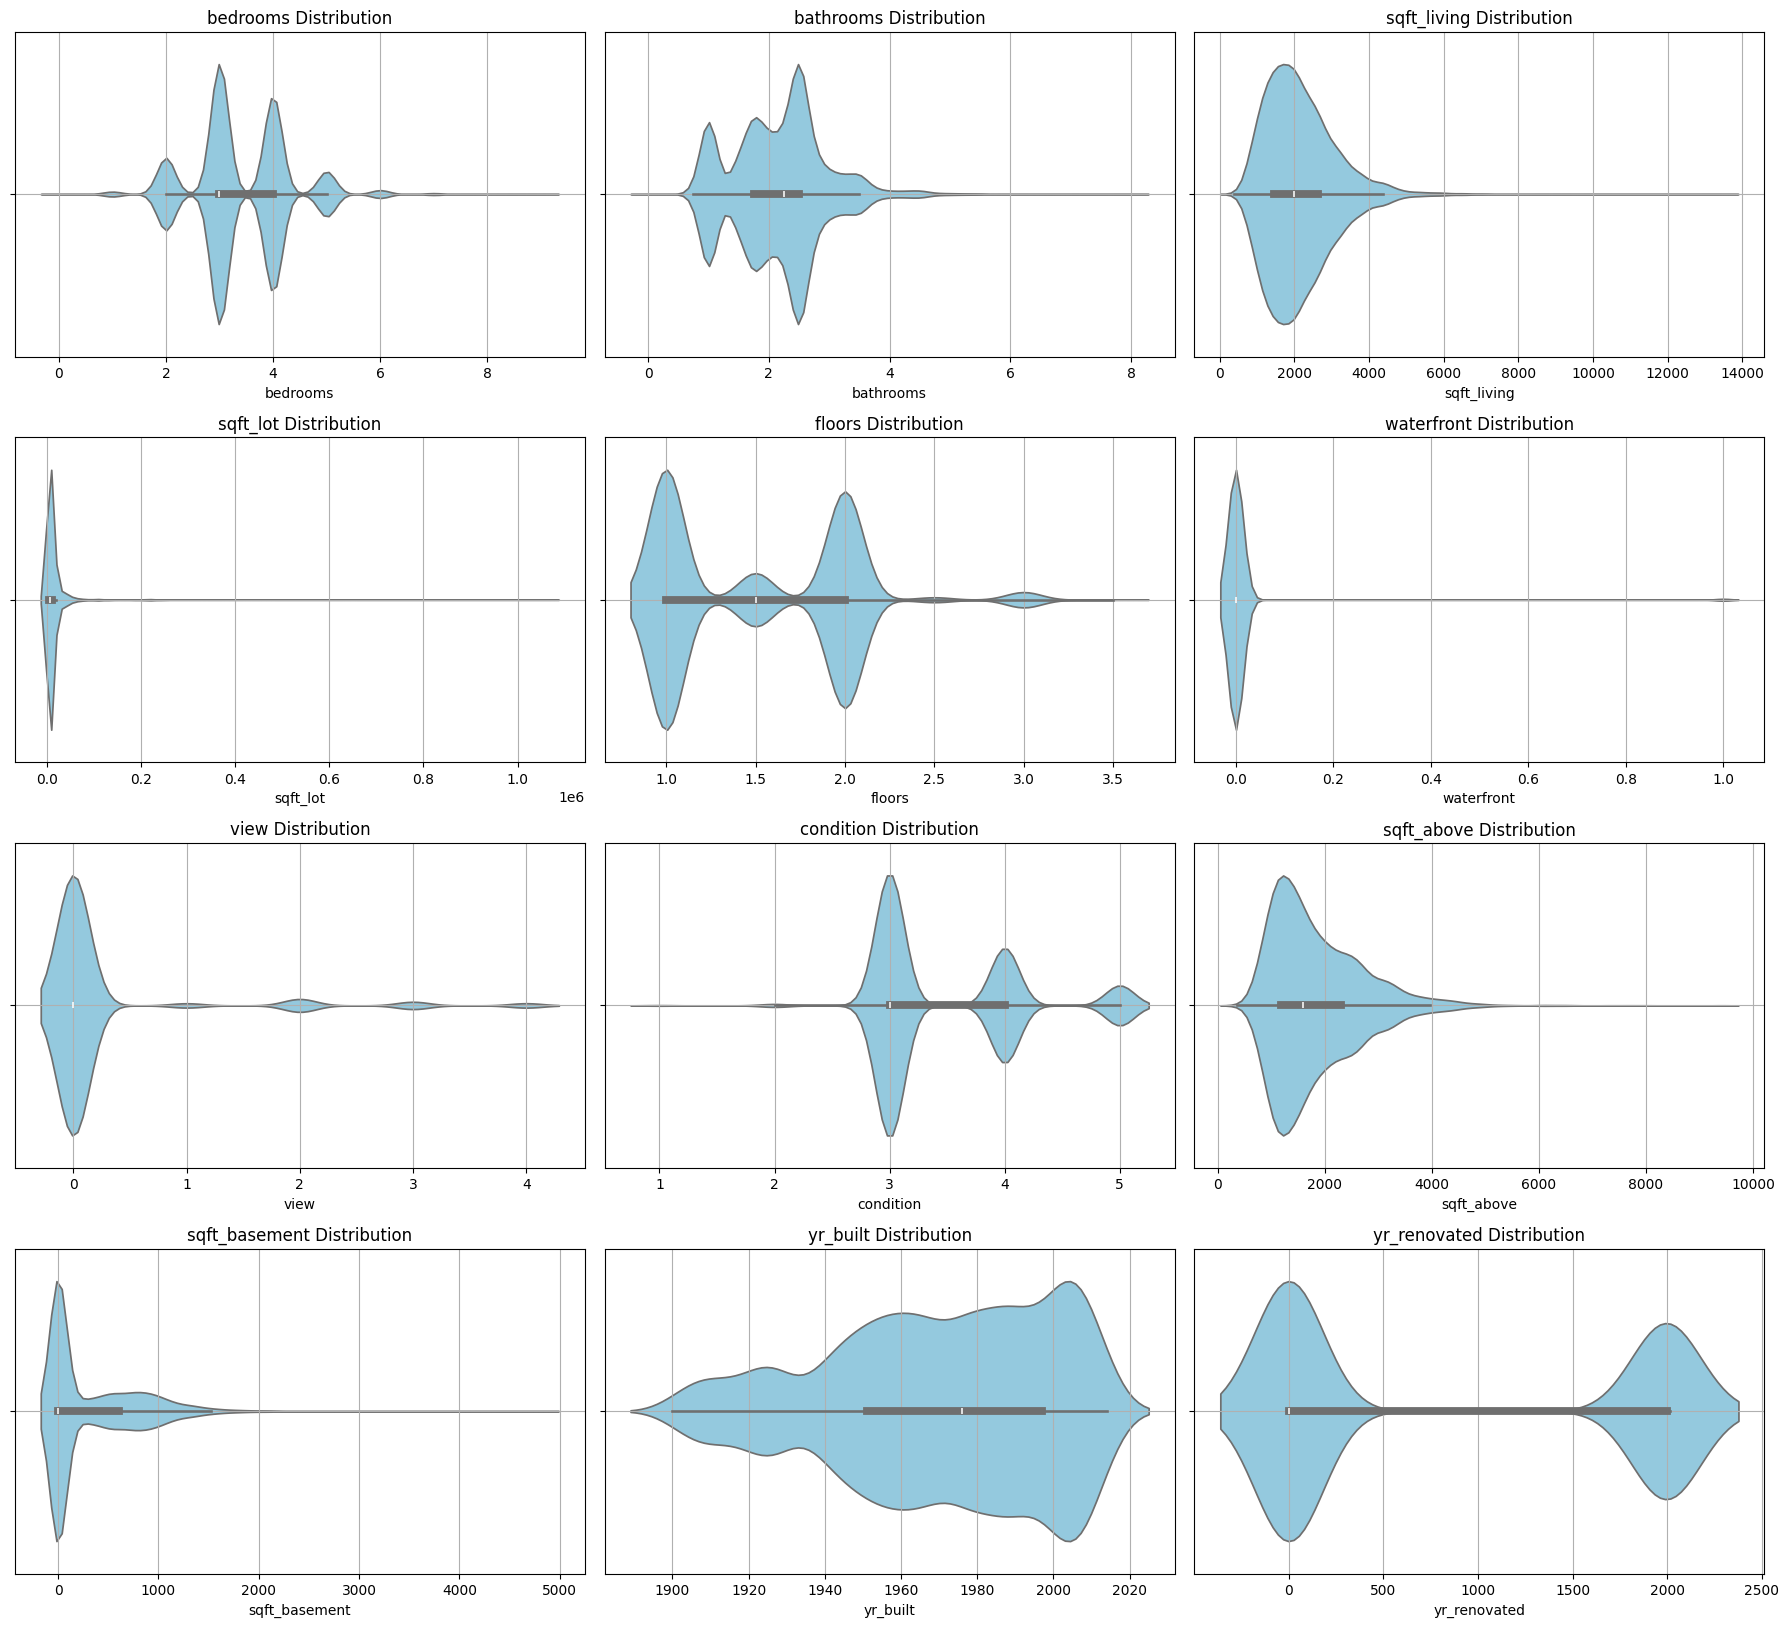

In [96]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(len(numerical_features)//3 + 1, 3, figsize=(18, 20))

for i, col in enumerate(numerical_features):
    row, col_idx = divmod(i, 3)
    sns.violinplot(x=col, data=df, ax=axes[row, col_idx], color="skyblue")
    axes[row, col_idx].set_title(f'{col} Distribution')
    axes[row, col_idx].grid(True)


# extra empty plots remove karne ke liye
for j in range(i+1, axes.size):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

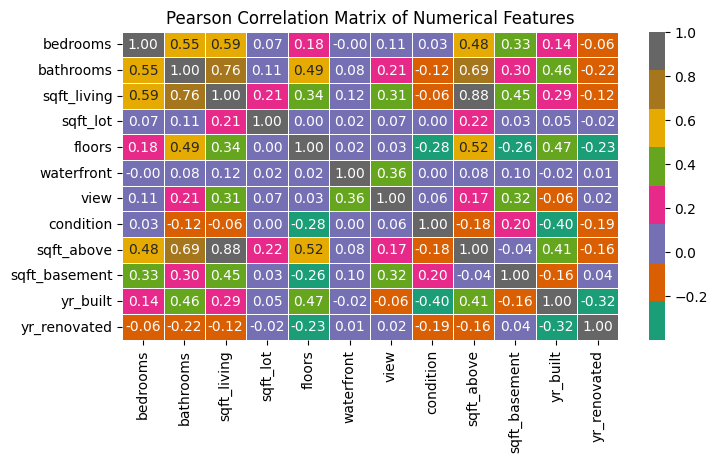

In [99]:
pearson_correlation_matrix = df[numerical_features].corr(method='pearson') # (good for linear relationships)

plt.figure(figsize=(8, 4))
sns.heatmap(pearson_correlation_matrix, annot=True, fmt=".2f",cmap='Dark2',linewidths=0.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

In [104]:
X = df
Y = y

In [105]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [109]:
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,...,False,False,True,False,False,False,False,False,False,False
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,...,False,True,False,False,False,False,False,False,False,False
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,...,False,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,...,False,False,False,False,False,False,False,False,False,False


In [111]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [114]:
predictions = model.predict(x_test)

In [115]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 129988.19466149708
R2 Score: 0.671341833598412


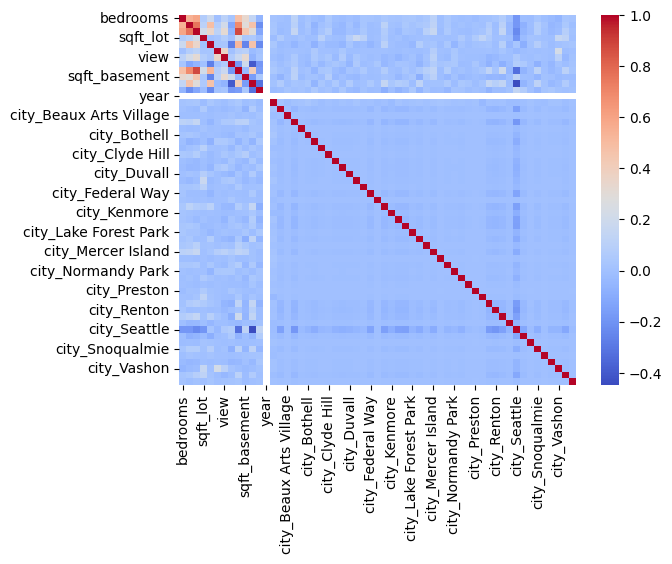

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()